In [2]:
from utlis import *
from config import *
from data import *
from model import *
from trainer import *
from sae import *
from transformers import BertTokenizer
from torch.utils.data import DataLoader
from torch.optim import AdamW


In [3]:
from analysis import *

In [4]:
device = get_device()
datacon = DatasetConfig("/Users/jesanahammed/Desktop/IMDB/IMDB Dataset.csv", "csv", "review", "sentiment", 128)
modelcon = ModelConfig("bert-base-uncased", None)
tokenizer = BertTokenizer.from_pretrained(modelcon.model_name)

loader = DatasetLoader(datacon, tokenizer)
dataset, num_labels, label_map = loader.load()
print(num_labels)

modelcon.num_labels = num_labels

Map: 100%|██████████| 10000/10000 [00:01<00:00, 8174.91 examples/s]

2


In [5]:
trainingcon = TrainingConfig(32, 5, 2e-5, tokenizer)

In [6]:
train_loader = DataLoader(dataset["train"], batch_size=trainingcon.batch_size)
test_loader = DataLoader(dataset["test"], batch_size=trainingcon.batch_size)

In [7]:
model = BERTClassifier(modelcon, device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7316.50it/s]


In [8]:
optimizer = AdamW(model.model.parameters(), lr=trainingcon.lr)

In [9]:
trainer = Trainer(model.model, optimizer, device, datacon, trainingcon)

In [10]:
trainer.train(train_loader, trainingcon.epochs)

KeyboardInterrupt: 

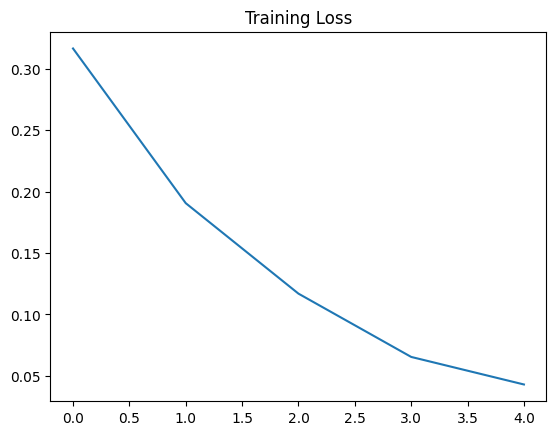

In [20]:
trainer.plot_loss()

In [21]:
trainer.evaluate(test_loader)

Confusion Matrix:
 [[4522  536]
 [ 496 4446]]


In [22]:
model.save("outputs/models/bert")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.83it/s]


In [11]:
model.load("outputs/models/bert")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7614.50it/s]


In [12]:
dataset.set_format(type=None)  # IMPORTANT

#N = 100

texts = dataset["test"]["review"]#[:N]
true_labels = torch.tensor(dataset["test"]["label"])

print(texts)
print(true_labels)

Y = trainer.get_bert_predictions(texts)
print(Y)

Column(["I have personally seen many Disney movies in my lifetime, though absolutely none of them match up in any way to Bedknobs and Broomsticks. Although I personally wouldn't have crossed live-action with animation, it was an improvement on trying to dress people up as animation characters. The movie pits three evacuees from world war two who are sent to stay with a silent and socially awkward woman in the country. I would have to say that the casting was brilliant. Angela Landsbury made a perfect Miss Price, while David Thomilson made a great desperate entertainer love interest. Endings always surprise me and this was no exception. It was neither happy nor sad, though I do not know if this was intentional. The dialog wasn't great, but considering it was designed to be a kid's movie, that is alright. Overall, I would give the performance nine out of ten, the dialog six out of ten, the casting nine out of ten and the costumes eight out of ten.", "Haines is excellent as the brash cade

In [2]:
# saeconfig = gemmaConfig("google/gemma-2b", "gemma-scope-2b-pt-res-canonical", "layer_20/width_16k/canonical",
#                      2, texts, device
#                      )


NameError: name 'SAEConfig' is not defined

In [12]:
# saeobj = GemmaScope(saeconfig)

In [3]:
# Z = saeobj.compute_sae_activation()

In [13]:
saeconfig = SAEConfig(
    model_name="gpt2",
    sae_release="gpt2-small-res-jb",
    sae_id="layer_8/width_16384/canonical",
    layer=8,
    batch_size=4,
    texts=texts,
    device="cpu"   # or "mps"
)

saeobj = ModelWithSAE(saeconfig)
Z = saeobj.compute_sae()
print(Z.shape)

OSError: We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.
Check your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

In [18]:
import sae_lens

print(dir(sae_lens))

['ActivationsStore', 'BatchTopKTrainingSAE', 'BatchTopKTrainingSAEConfig', 'CacheActivationsRunner', 'CacheActivationsRunnerConfig', 'GatedSAE', 'GatedSAEConfig', 'GatedTrainingSAE', 'GatedTrainingSAEConfig', 'HookedSAETransformer', 'JumpReLUSAE', 'JumpReLUSAEConfig', 'JumpReLUSkipTranscoder', 'JumpReLUSkipTranscoderConfig', 'JumpReLUTrainingSAE', 'JumpReLUTrainingSAEConfig', 'JumpReLUTranscoder', 'JumpReLUTranscoderConfig', 'LanguageModelSAERunnerConfig', 'LanguageModelSAETrainingRunner', 'LoggingConfig', 'MatchingPursuitSAE', 'MatchingPursuitSAEConfig', 'MatchingPursuitTrainingSAE', 'MatchingPursuitTrainingSAEConfig', 'MatryoshkaBatchTopKTrainingSAE', 'MatryoshkaBatchTopKTrainingSAEConfig', 'PretokenizeRunner', 'PretokenizeRunnerConfig', 'PretrainedSaeDiskLoader', 'PretrainedSaeHuggingfaceLoader', 'SAE', 'SAEConfig', 'SAETrainer', 'SAETrainingRunner', 'SAETransformerBridge', 'SkipTranscoder', 'SkipTranscoderConfig', 'StandardSAE', 'StandardSAEConfig', 'StandardTrainingSAE', 'Standard

In [28]:
saeconfig = SAEConfig(
    768, 5000, 1e-3, 32, 10, model, train_loader, 5000, device
)

In [14]:
import sys
print(sys.executable)

/Users/jesanahammed/Math498-Project/.venv/bin/python


In [20]:
from huggingface_hub import get_token

token = get_token()
print(token[:10] if token else None)

hf_OnNMfWc


In [1]:
from transformers import AutoConfig
from huggingface_hub import get_token

cfg = AutoConfig.from_pretrained(
    "google/gemma-2b",
    token=get_token(),
    force_download=True
)

print("SUCCESS")
print(cfg.model_type)

/Users/jesanahammed/Math498-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: Force download failed due to the above error.

In [9]:
ts = trainsae(saeconfig)

100%|██████████| 157/157 [00:00<00:00, 355.77it/s]


Epoch 0: Loss 0.1900


100%|██████████| 157/157 [00:00<00:00, 344.56it/s]


Epoch 1: Loss 0.0553


100%|██████████| 157/157 [00:00<00:00, 343.21it/s]


...

Epoch 7: Loss 0.0310


100%|██████████| 157/157 [00:00<00:00, 298.94it/s]


Epoch 8: Loss 0.0308


100%|██████████| 157/157 [00:00<00:00, 335.86it/s]


Epoch 9: Loss 0.0329


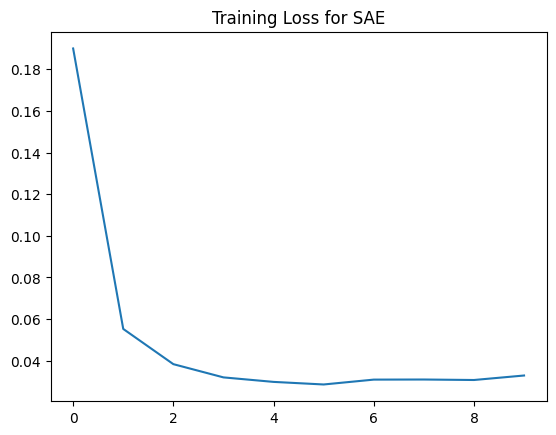

In [10]:
sae, H_norm, Y = ts.train_sae()

In [12]:
Z = get_feature_activations(sae, H_norm, device)

In [13]:
def plot(Z):
    

    vals = Z.detach().cpu().numpy().flatten()

    plt.figure(figsize=(6,4))
    plt.hist(vals, bins=100)
    plt.title("Activation Distribution")
    plt.xlabel("Activation value")
    plt.ylabel("Frequency")
    plt.show()

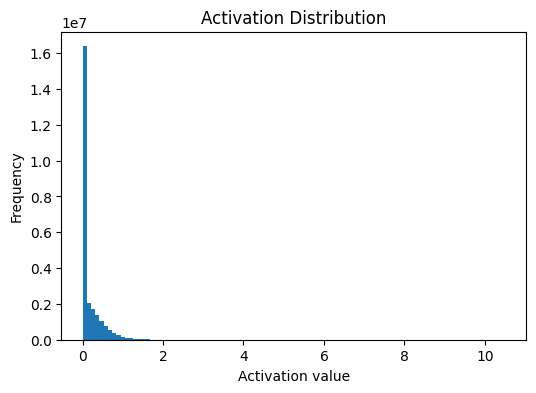

In [14]:
plot(Z)

In [14]:
importance = compute_feature_importance(Z, Y)
print(importance)
# top_features = get_top_features(importance, k=10)

# print("Top features:", top_features)

tensor([0.0134, 0.0956, 0.0330,  ..., 0.0076, 0.0012, 0.0085])


In [15]:
p_values = compute_ttest(Z, Y)
reg_weights = compute_logistic_importance(Z, Y)

In [16]:
score = combine_scores(importance, p_values, reg_weights)

In [17]:
top_features = get_top_features(score, k=10)

print("Top features:", top_features)

Top features: tensor([2089, 4019, 3184, 2193,   89, 3383, 3092, 3933,  545,   50])


In [21]:
dataset.set_format(type=None) 
for f in top_features:
    #print(dataset["train"].column_names)
    show_top_texts(f, Z, dataset, text_col=datacon.text_column)


===== Feature 2089 =====

This one is a great one! Robert De Niro and Cuba Gooding have teamed up to make a powerful and very influential film. This is the true story of the first black US Navy diver and the obstacles he faced in attaining his certification at the hands of a racist Master diver. Along the way, he must also face plain old bigotry from all of his classmates, none of whom want him in their class. They move out of the barracks when he arrives. Ultimately, he becomes certified and goes on to have a great career as a US Navy diver. Watch this one! It's a great tale of courage and honor. As the story unfolds, we get to watch racism slowly dissipate and everyone begins to respect men one at a time.
---
I watched this short moments ago on the Sundance Film Festival website, and I must say it is absolutely astounding. I expected it to be entertaining - like all of the Sundance shorts - but I wasn't prepared for such deep sadness and yet also a sense of passion and beauty. <br /